# TinyMML CPU showcase

This notebook trains the same small CNN and MLP with TinyMML and Keras/TensorFlow. It is a reproducible correctness and performance demonstration, not a claim that the implementations are equally optimized. TinyMML uses NCHW images; Keras uses NHWC. Downloads, preprocessing, and model construction are excluded from training timings.

In [1]:
# Set CPU/thread policy before importing numerical libraries.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
for variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[variable] = "1"

PROFILE = os.environ.get("TINYMML_PROFILE", "quick").lower()
PROFILES = {
    "quick": {
        "cifar_train": 1_000, "cifar_test": 250,
        "cifar_epochs": 3, "diabetes_epochs": 150, "repeats": 5,
    },
    "full": {
        "cifar_train": 10_000, "cifar_test": 2_000,
        "cifar_epochs": 5, "diabetes_epochs": 300, "repeats": 10,
    },
}
if PROFILE not in PROFILES:
    raise ValueError("TINYMML_PROFILE must be 'quick' or 'full'")
CONFIG = {**PROFILES[PROFILE], "batch_size": 32, "seed": 42}
CONFIG

{'cifar_train': 1000,
 'cifar_test': 250,
 'cifar_epochs': 3,
 'diabetes_epochs': 150,
 'repeats': 5,
 'batch_size': 32,
 'seed': 42}

In [2]:
from io import BytesIO
from pathlib import Path
import importlib.metadata as metadata
import platform
import sys
from time import perf_counter

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from sklearn.datasets import load_diabetes
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, mean_absolute_error,
    mean_squared_error, r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

threadpool_limits(limits=1)
import tensorflow as tf
import keras

tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []

environment = {
    "profile": PROFILE,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "logical CPU count": os.cpu_count(),
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "TensorFlow": tf.__version__,
    "Keras": keras.__version__,
    "scikit-learn": metadata.version("scikit-learn"),
    "TinyTensor CUDA available": tt.cuda_available(),
    "TensorFlow visible GPUs": tf.config.get_visible_devices("GPU"),
}
display(Markdown("## Environment\n" + "\n".join(f"- **{key}:** {value}" for key, value in environment.items())))
display(Markdown("### Exact profile\n```python\n" + repr(CONFIG) + "\n```"))

## Environment
- **profile:** quick
- **platform:** macOS-26.5.1-arm64-arm-64bit-Mach-O
- **machine:** arm64
- **logical CPU count:** 8
- **Python:** 3.13.14
- **NumPy:** 2.4.3
- **TensorFlow:** 2.21.0
- **Keras:** 3.15.0
- **scikit-learn:** 1.9.0
- **TinyTensor CUDA available:** False
- **TensorFlow visible GPUs:** []

### Exact profile
```python
{'cifar_train': 1000, 'cifar_test': 250, 'cifar_epochs': 3, 'diabetes_epochs': 150, 'repeats': 5, 'batch_size': 32, 'seed': 42}
```

In [3]:
def stratified_indices(labels, sample_count, seed):
    """Pick an equal, deterministic number of CIFAR-10 samples per class."""
    labels = np.asarray(labels).reshape(-1)
    if sample_count % 10:
        raise ValueError("CIFAR-10 sample count must be divisible by 10")
    rng = np.random.default_rng(seed)
    per_class = sample_count // 10
    indices = np.concatenate([
        rng.choice(np.flatnonzero(labels == label), per_class, replace=False)
        for label in range(10)
    ])
    rng.shuffle(indices)
    return indices


def one_hot(labels, class_count=10):
    return np.eye(class_count, dtype=np.float32)[np.asarray(labels).reshape(-1)]


def cached_huggingface_cifar(split):
    """Download one verified CIFAR-10 parquet shard, then reuse the cache."""
    files = {
        "train": ("train-00000-of-00001.parquet", "8428b53a88a11ac374111006708df51469e315a22ac6d66470afd9c78d2ae883"),
        "test": ("test-00000-of-00001.parquet", "841389e6f2d64f28bf17310e430aebac20ec3ba611a3c5e231dc93c645ce84de"),
    }
    filename, sha256 = files[split]
    origin = f"https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/{filename}?download=true"
    return Path(keras.utils.get_file(
        fname=filename, origin=origin, file_hash=sha256,
        cache_dir=str(ROOT / "data"), cache_subdir="cifar10",
    ))


def load_cifar_subset(parquet_path, sample_count, seed):
    """Read only selected image row groups from a CIFAR-10 parquet shard."""
    labels = pq.read_table(parquet_path, columns=["label"])["label"].to_numpy()
    indices = stratified_indices(labels, sample_count, seed)
    parquet = pq.ParquetFile(parquet_path)
    row_group_size = parquet.metadata.row_group(0).num_rows
    images = np.empty((sample_count, 32, 32, 3), dtype=np.uint8)
    for row_group in np.unique(indices // row_group_size):
        output_positions = np.flatnonzero(indices // row_group_size == row_group)
        encoded_images = parquet.read_row_group(int(row_group), columns=["img"])["img"].to_pylist()
        for output_position in output_positions:
            local_row = int(indices[output_position] % row_group_size)
            image_bytes = encoded_images[local_row]["bytes"]
            images[output_position] = np.asarray(Image.open(BytesIO(image_bytes)).convert("RGB"))
    return images, labels[indices].astype(np.int64), indices


def benchmark_inference(predict, sample_count, repeats):
    predict()  # warm-up excluded
    durations = []
    for _ in range(repeats):
        started = perf_counter()
        predict()
        durations.append(perf_counter() - started)
    median_seconds = float(np.median(durations))
    return {
        "latency_ms": 1_000.0 * median_seconds,
        "samples_per_second": sample_count / median_seconds,
    }


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    return "\n".join([header, divider, *body])

## CIFAR-10 image classification

Both models use `Conv2D(8, 3, stride=2, padding=1) → ReLU → Flatten → Linear(32) → ReLU → Linear(10)`, Adam at `1e-3`, batch size 32, and logits cross-entropy. The sampled examples are identical; only the image memory layout differs.

In [4]:
cifar_train_path = cached_huggingface_cifar("train")
cifar_test_path = cached_huggingface_cifar("test")
cifar_x_train_nhwc, cifar_y_train, train_indices = load_cifar_subset(
    cifar_train_path, CONFIG["cifar_train"], CONFIG["seed"],
)
cifar_x_test_nhwc, cifar_y_test, test_indices = load_cifar_subset(
    cifar_test_path, CONFIG["cifar_test"], CONFIG["seed"] + 1,
)
cifar_x_train_nhwc = cifar_x_train_nhwc.astype(np.float32) / 255.0
cifar_x_test_nhwc = cifar_x_test_nhwc.astype(np.float32) / 255.0
cifar_x_train_nchw = np.ascontiguousarray(cifar_x_train_nhwc.transpose(0, 3, 1, 2))
cifar_x_test_nchw = np.ascontiguousarray(cifar_x_test_nhwc.transpose(0, 3, 1, 2))
cifar_y_train_one_hot = one_hot(cifar_y_train)
cifar_y_test_one_hot = one_hot(cifar_y_test)

tiny_cifar = tm.Model([
    tm.Conv2D(8, 3, stride=2, padding=1, init="he"),
    tm.ReLU(), tm.Flatten(), tm.Linear(32, init="he"),
    tm.ReLU(), tm.Linear(10),
])
tiny_cifar.build(list(cifar_x_train_nchw.shape))
tiny_cifar_optimizer = tm.Adam(tiny_cifar.parameters(), lr=1e-3)
tiny_cifar_loss = tm.CrossEntropyLoss()

keras_cifar = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(8, 3, strides=2, padding="same", kernel_initializer="he_normal"),
    keras.layers.ReLU(), keras.layers.Flatten(),
    keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(10),
])
keras_cifar.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
print("Prepared shapes:", cifar_x_train_nchw.shape, cifar_x_train_nhwc.shape)

Prepared shapes: (1000, 3, 32, 32) (1000, 32, 32, 3)


In [5]:
started = perf_counter()
tiny_cifar_history = tiny_cifar.fit(
    cifar_x_train_nchw, cifar_y_train_one_hot,
    epochs=CONFIG["cifar_epochs"], batch_size=CONFIG["batch_size"],
    optimizer=tiny_cifar_optimizer, loss_fn=tiny_cifar_loss,
    metric="accuracy", verbose=False,
)
tiny_cifar_train_seconds = perf_counter() - started

started = perf_counter()
keras_cifar_history = keras_cifar.fit(
    cifar_x_train_nhwc, cifar_y_train_one_hot,
    epochs=CONFIG["cifar_epochs"], batch_size=CONFIG["batch_size"],
    shuffle=True, verbose=0,
)
keras_cifar_train_seconds = perf_counter() - started

tiny_cifar_logits = tiny_cifar.predict(cifar_x_test_nchw, batch_size=CONFIG["batch_size"])
keras_cifar_logits = keras_cifar.predict(cifar_x_test_nhwc, batch_size=CONFIG["batch_size"], verbose=0)
tiny_cifar_predictions = tiny_cifar_logits.argmax(axis=1)
keras_cifar_predictions = keras_cifar_logits.argmax(axis=1)
tiny_cifar_accuracy = accuracy_score(cifar_y_test, tiny_cifar_predictions)
keras_cifar_accuracy = accuracy_score(cifar_y_test, keras_cifar_predictions)

tiny_cifar_inference = benchmark_inference(
    lambda: tiny_cifar.predict(cifar_x_test_nchw, batch_size=CONFIG["batch_size"]),
    len(cifar_x_test_nchw), CONFIG["repeats"],
)
keras_cifar_inference = benchmark_inference(
    lambda: keras_cifar(cifar_x_test_nhwc, training=False).numpy(),
    len(cifar_x_test_nhwc), CONFIG["repeats"],
)

cifar_results = [
    {"library": "TinyMML", "accuracy": f"{tiny_cifar_accuracy:.3f}",
     "training_s": f"{tiny_cifar_train_seconds:.2f}",
     "inference_ms": f"{tiny_cifar_inference['latency_ms']:.2f}",
     "samples/s": f"{tiny_cifar_inference['samples_per_second']:.1f}"},
    {"library": "Keras", "accuracy": f"{keras_cifar_accuracy:.3f}",
     "training_s": f"{keras_cifar_train_seconds:.2f}",
     "inference_ms": f"{keras_cifar_inference['latency_ms']:.2f}",
     "samples/s": f"{keras_cifar_inference['samples_per_second']:.1f}"},
]
display(Markdown(markdown_table(cifar_results, ["library", "accuracy", "training_s", "inference_ms", "samples/s"])))

| library | accuracy | training_s | inference_ms | samples/s |
| --- | --- | --- | --- | --- |
| TinyMML | 0.220 | 3.80 | 73.36 | 3408.1 |
| Keras | 0.276 | 1.05 | 8.96 | 27895.3 |

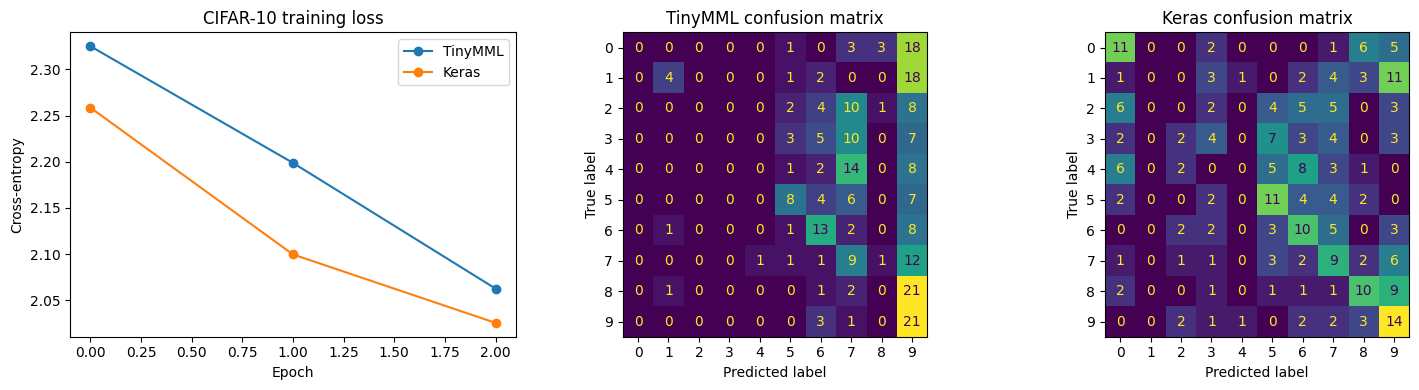

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(tiny_cifar_history["loss"], marker="o", label="TinyMML")
axes[0].plot(keras_cifar_history.history["loss"], marker="o", label="Keras")
axes[0].set(title="CIFAR-10 training loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(cifar_y_test, tiny_cifar_predictions, ax=axes[1], colorbar=False)
axes[1].set_title("TinyMML confusion matrix")
ConfusionMatrixDisplay.from_predictions(cifar_y_test, keras_cifar_predictions, ax=axes[2], colorbar=False)
axes[2].set_title("Keras confusion matrix")
plt.tight_layout()
plt.show()

assert np.isfinite(tiny_cifar_history["loss"]).all()
assert tiny_cifar_history["loss"][-1] < tiny_cifar_history["loss"][0]
assert tiny_cifar_accuracy >= 0.15, f"TinyMML CIFAR accuracy too low: {tiny_cifar_accuracy:.3f}"

## Diabetes regression

The deterministic 80/20 split is standardized using training data only. Both models use `10 → 32 → 16 → 1`, ReLU, Adam at `1e-2` with `1e-3` weight decay, batch size 32, and MSE. Predictions are inverse-transformed before MAE, RMSE, and R² are computed.

In [7]:
np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
diabetes = load_diabetes()
dx_train, dx_test, dy_train, dy_test = train_test_split(
    diabetes.data.astype(np.float32), diabetes.target.astype(np.float32),
    test_size=0.2, random_state=CONFIG["seed"],
)
x_scaler, y_scaler = StandardScaler(), StandardScaler()
dx_train_scaled = x_scaler.fit_transform(dx_train).astype(np.float32)
dx_test_scaled = x_scaler.transform(dx_test).astype(np.float32)
dy_train_scaled = y_scaler.fit_transform(dy_train[:, None]).astype(np.float32)
dy_test_scaled = y_scaler.transform(dy_test[:, None]).astype(np.float32)

tiny_diabetes = tm.Model([
    tm.Linear(32, init="he"), tm.ReLU(),
    tm.Linear(16, init="he"), tm.ReLU(), tm.Linear(1),
])
tiny_diabetes.build(list(dx_train_scaled.shape))
tiny_diabetes_optimizer = tm.Adam(tiny_diabetes.parameters(), lr=1e-2, weight_decay=1e-3)
tiny_diabetes_loss = tm.MSELoss()

keras_diabetes = keras.Sequential([
    keras.layers.Input(shape=(10,)),
    keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dense(1),
])
keras_diabetes.compile(optimizer=keras.optimizers.Adam(1e-2, weight_decay=1e-3), loss="mse")

In [8]:
started = perf_counter()
tiny_diabetes_history = tiny_diabetes.fit(
    dx_train_scaled, dy_train_scaled, epochs=CONFIG["diabetes_epochs"],
    batch_size=CONFIG["batch_size"], optimizer=tiny_diabetes_optimizer,
    loss_fn=tiny_diabetes_loss, verbose=False,
)
tiny_diabetes_train_seconds = perf_counter() - started

started = perf_counter()
keras_diabetes_history = keras_diabetes.fit(
    dx_train_scaled, dy_train_scaled, epochs=CONFIG["diabetes_epochs"],
    batch_size=CONFIG["batch_size"], shuffle=True, verbose=0,
)
keras_diabetes_train_seconds = perf_counter() - started

tiny_diabetes_scaled_predictions = tiny_diabetes.predict(dx_test_scaled, batch_size=CONFIG["batch_size"])
keras_diabetes_scaled_predictions = keras_diabetes.predict(dx_test_scaled, batch_size=CONFIG["batch_size"], verbose=0)
tiny_diabetes_predictions = y_scaler.inverse_transform(tiny_diabetes_scaled_predictions).reshape(-1)
keras_diabetes_predictions = y_scaler.inverse_transform(keras_diabetes_scaled_predictions).reshape(-1)
mean_baseline = np.full_like(dy_test, dy_train.mean())
baseline_mae = mean_absolute_error(dy_test, mean_baseline)

tiny_diabetes_inference = benchmark_inference(
    lambda: tiny_diabetes.predict(dx_test_scaled, batch_size=CONFIG["batch_size"]),
    len(dx_test_scaled), CONFIG["repeats"],
)
keras_diabetes_inference = benchmark_inference(
    lambda: keras_diabetes(dx_test_scaled, training=False).numpy(),
    len(dx_test_scaled), CONFIG["repeats"],
)

def regression_row(library, predictions, training_seconds, inference):
    return {
        "library": library,
        "MAE": f"{mean_absolute_error(dy_test, predictions):.2f}",
        "RMSE": f"{mean_squared_error(dy_test, predictions) ** 0.5:.2f}",
        "R2": f"{r2_score(dy_test, predictions):.3f}",
        "training_s": f"{training_seconds:.2f}",
        "inference_ms": f"{inference['latency_ms']:.3f}",
        "samples/s": f"{inference['samples_per_second']:.1f}",
    }

diabetes_results = [
    regression_row("TinyMML", tiny_diabetes_predictions, tiny_diabetes_train_seconds, tiny_diabetes_inference),
    regression_row("Keras", keras_diabetes_predictions, keras_diabetes_train_seconds, keras_diabetes_inference),
]
display(Markdown(f"Train-mean MAE baseline: **{baseline_mae:.2f}**\n\n" + markdown_table(
    diabetes_results, ["library", "MAE", "RMSE", "R2", "training_s", "inference_ms", "samples/s"]
)))

Train-mean MAE baseline: **64.01**

| library | MAE | RMSE | R2 | training_s | inference_ms | samples/s |
| --- | --- | --- | --- | --- | --- | --- |
| TinyMML | 53.53 | 69.95 | 0.076 | 1.24 | 0.417 | 213322.3 |
| Keras | 50.49 | 70.31 | 0.067 | 3.48 | 1.825 | 48758.2 |

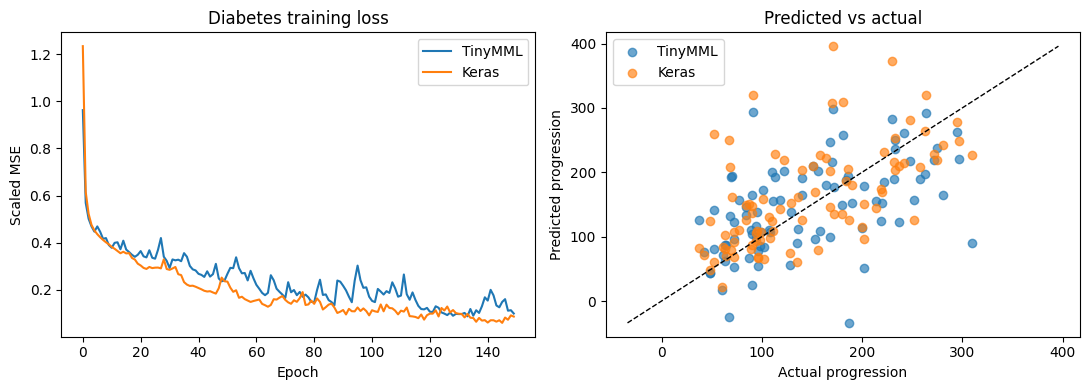

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tiny_diabetes_history["loss"], label="TinyMML")
axes[0].plot(keras_diabetes_history.history["loss"], label="Keras")
axes[0].set(title="Diabetes training loss", xlabel="Epoch", ylabel="Scaled MSE")
axes[0].legend()
axes[1].scatter(dy_test, tiny_diabetes_predictions, alpha=0.65, label="TinyMML")
axes[1].scatter(dy_test, keras_diabetes_predictions, alpha=0.65, label="Keras")
limits = [min(dy_test.min(), tiny_diabetes_predictions.min(), keras_diabetes_predictions.min()),
          max(dy_test.max(), tiny_diabetes_predictions.max(), keras_diabetes_predictions.max())]
axes[1].plot(limits, limits, "k--", linewidth=1)
axes[1].set(title="Predicted vs actual", xlabel="Actual progression", ylabel="Predicted progression")
axes[1].legend()
plt.tight_layout()
plt.show()

assert np.isfinite(tiny_diabetes_history["loss"]).all()
assert tiny_diabetes_history["loss"][-1] < tiny_diabetes_history["loss"][0]
assert mean_absolute_error(dy_test, tiny_diabetes_predictions) < baseline_mae
tiny_diabetes_r2 = r2_score(dy_test, tiny_diabetes_predictions)
keras_diabetes_r2 = r2_score(dy_test, keras_diabetes_predictions)
assert tiny_diabetes_r2 > 0.0, f"TinyMML Diabetes R2 must be positive, got {tiny_diabetes_r2:.3f}"
assert keras_diabetes_r2 > 0.0, f"Keras Diabetes R2 must be positive, got {keras_diabetes_r2:.3f}"

## Interpretation

Keras/TensorFlow is an industrial, heavily optimized framework; TinyMML is a compact educational implementation. Timing differences are therefore expected. The useful acceptance signal is that TinyMML's end-to-end autograd trains both architectures, produces finite decreasing losses, beats the stated baselines, and reports transparent CPU measurements.